<a href="https://colab.research.google.com/github/amina-nasrin/Graph-Neural-Network/blob/main/pagerank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [ ]:
G = nx.DiGraph()

In [ ]:
G.add_edges_from([(0,1),(1,4),(2,0),(2,1),(2,3),(2,4),(3,2),(3,4),(4,3)])

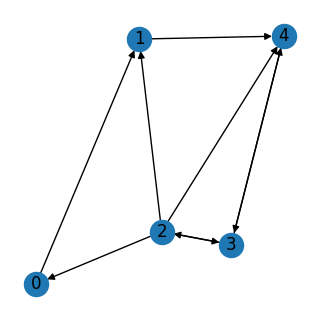

In [ ]:
plt.figure(figsize=(3, 3))
nx.draw(G, with_labels=True)

In [ ]:
A = nx.adjacency_matrix(G, nodelist=range(5))
A = A.todense()
A = np.transpose(A)
print(A)
D = np.diag(list(dict(G.out_degree(range(5))).values()))
print(D)
print(np.linalg.inv(D))
P = np.matmul(A,np.linalg.inv(D))
print(P)

[[0 0 1 0 0]
 [1 0 1 0 0]
 [0 0 0 1 0]
 [0 0 1 0 1]
 [0 1 1 1 0]]
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 4 0 0]
 [0 0 0 2 0]
 [0 0 0 0 1]]
[[1.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.  ]
 [0.   0.   0.25 0.   0.  ]
 [0.   0.   0.   0.5  0.  ]
 [0.   0.   0.   0.   1.  ]]
[[0.   0.   0.25 0.   0.  ]
 [1.   0.   0.25 0.   0.  ]
 [0.   0.   0.   0.5  0.  ]
 [0.   0.   0.25 0.   1.  ]
 [0.   1.   0.25 0.5  0.  ]]


In [ ]:
x_old = 0.2*np.ones(5)
print(x_old)

[0.2 0.2 0.2 0.2 0.2]


In [ ]:
x_new = np.matmul(P,x_old)
print(x_new)

[0.05 0.25 0.1  0.25 0.35]


In [ ]:
x_old = x_new
x_new = np.matmul(P,x_old)
print(x_new)

[0.025 0.075 0.125 0.375 0.4  ]


In [ ]:
iter = 1
while iter <= 100:
    x_old = x_new
    x_new = np.matmul(P,x_old)
    iter += 1

print(x_new)

[0.04545455 0.09090909 0.18181818 0.36363636 0.31818182]


In [ ]:
pagerank = nx.pagerank(G,alpha=1)
print(sorted(pagerank.items()))

[(0, 0.04545443879223966), (1, 0.09090938611707314), (2, 0.18181799786525515), (3, 0.36363721753778), (4, 0.3181809596876519)]


In [ ]:
G1 = nx.DiGraph()

In [ ]:
G1.add_edges_from([(0,1),(2,0),(2,1),(2,3),(2,4),(3,2),(3,4),(4,3)])

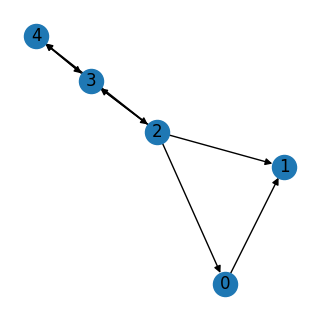

In [ ]:
plt.figure(figsize=(3, 3))
nx.draw(G1, with_labels=True)

In [ ]:
A1 = nx.adjacency_matrix(G1, nodelist=range(5))
A1 = A1.todense()
A1 = np.transpose(A1)
print(A1)
outdegrees = np.array(list(dict(G1.out_degree(range(5))).values()))
with np.errstate(divide='ignore'):
  reciprocal = np.where(outdegrees != 0, 1/outdegrees, 0)
D1_inv = np.diag(reciprocal)
P1 = np.matmul(A1,D1_inv)
print(P1)

[[0 0 1 0 0]
 [1 0 1 0 0]
 [0 0 0 1 0]
 [0 0 1 0 1]
 [0 0 1 1 0]]
[[0.   0.   0.25 0.   0.  ]
 [1.   0.   0.25 0.   0.  ]
 [0.   0.   0.   0.5  0.  ]
 [0.   0.   0.25 0.   1.  ]
 [0.   0.   0.25 0.5  0.  ]]


In [ ]:
x_old = 0.2*np.ones(5)
x_new = np.matmul(P1,x_old)
print(x_new)

[0.05 0.25 0.1  0.25 0.15]


In [ ]:
x_old = x_new
x_new = np.matmul(P1,x_old)
print(x_new)

[0.025 0.075 0.125 0.175 0.15 ]


In [ ]:
x_old = x_new
x_new = np.matmul(P1,x_old)
print(x_new)

[0.03125 0.05625 0.0875  0.18125 0.11875]


In [ ]:
iter = 1
while iter <= 100:
    x_old = x_new
    x_new = np.matmul(P1,x_old)
    iter += 1

print(x_new)

[5.00324707e-08 1.07136336e-07 1.75347017e-07 3.07266219e-07
 2.25379487e-07]


In [ ]:
pagerank1 = nx.pagerank(G1,alpha=1)
print(sorted(pagerank1.items()))

[(0, 0.0806453261787056), (1, 0.16129023490705907), (2, 0.19354802678053884), (3, 0.3225811505869257), (4, 0.24193526154677103)]


In [ ]:
pagerank2 = nx.pagerank(G1)
print(sorted(pagerank2.items()))

[(0, 0.10186291488841237), (1, 0.18844590197274635), (2, 0.18742019215590533), (3, 0.2950237398256601), (4, 0.22724725115727604)]
